In [1]:
import os
!git clone https://github.com/bencejdanko/bert-tweeteval

# ensure latest
os.chdir('/content/bert-tweeteval')
!cd /content/bert-tweeteval && git pull

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 172 (delta 107), reused 104 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 335.19 KiB | 744.00 KiB/s, done.
Resolving deltas: 100% (107/107), done.
Already up to date.


In [2]:
# copy over package
PACKAGE = "src"

import sys
sys.path.append(f"/content/bert-tweeteval/{PACKAGE}")

In [3]:
from download import download_and_split_dataset
from analysis import print_samples, print_distribution, calculate_ece
from zero_shot import DistilBERT_zero_shot_pipeline, DistilRoBERTa_zero_shot_pipeline, run_benchmarked_inference, run_zero_shot

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


In [4]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [5]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Testing set: {len(test_df)}")
print(f"Val set: {len(val_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Testing set: 1421
Val set: 374


In [6]:
print_samples(train_df, id_labels)

,Label,Tweet Text
1096,sadness,This weather making me dread work tonight
787,sadness,We express our deep concern about the suspensi...
2476,anger,@user why is there no disabled access at ponte...
1250,anger,Niggas never changed...even as a kid and a 29 ...
913,sadness,im so gloomy today


In [7]:
print_distribution(train_df, test_df, id_labels)


Data Split
Training set: 3257
Testing set:  1421

Class Distribution (Counts)
          Train Count  Test Count  Train %
label                                     
anger            1400         558    42.98
sadness           855         382    26.25
joy               708         358    21.74
optimism          294         123     9.03


In [8]:
test_df["distilbert_pred"] = run_zero_shot(test_df, DistilBERT_zero_shot_pipeline, candidate_labels , hypothesis_template)

In [9]:
test_df["distilroberta_pred"] = run_zero_shot(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, hypothesis_template)

In [10]:
print(test_df[["text", "label", "distilbert_pred", "distilroberta_pred"]].head())

                                                text  label distilbert_pred  \
0  #Deppression is real. Partners w/ #depressed p...      3        optimism   
1  @user Interesting choice of words... Are you c...      0             joy   
2  My visit to hospital for care triggered #traum...      3        optimism   
3  @user Welcome to #MPSVT! We are delighted to h...      1        optimism   
4                       What makes you feel #joyful?      1             joy   

  distilroberta_pred  
0            sadness  
1           optimism  
2            sadness  
3            sadness  
4            sadness  


In [11]:
results = {}

In [12]:
results["DistilBERT (WordPiece)"] = run_benchmarked_inference(test_df, DistilBERT_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [13]:
results["DistilRoBERTa (BPE)"] = run_benchmarked_inference(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [28]:
import pandas as pd
key_metrics = ["Accuracy", "Macro F1", "ECE", "Time/100"]
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose()

,Accuracy,Macro F1,ECE,Time/100
DistilBERT (WordPiece),0.083744,0.064219,0.167510,312.318607
DistilRoBERTa (BPE),0.217452,0.155317,0.032674,299.071175


In [15]:
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose().to_markdown()

'|                        |   Accuracy |   Macro F1 |       ECE |   Time/100 |\n|:-----------------------|-----------:|-----------:|----------:|-----------:|\n| DistilBERT (WordPiece) |  0.0837438 |  0.0642185 | 0.16751   |    312.319 |\n| DistilRoBERTa (BPE)    |  0.217452  |  0.155317  | 0.0326744 |    299.071 |'

In [16]:
import pandas as pd
report_df = pd.DataFrame(results["DistilBERT (WordPiece)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,1.000000,0.001792,0.003578,558.000000
joy,0.106897,0.086592,0.095679,358.000000
optimism,0.073477,0.666667,0.132365,123.000000
sadness,0.357143,0.013089,0.025253,382.000000
accuracy,0.083744,0.083744,0.083744,0.083744
macro avg,0.384379,0.192035,0.064219,1421.000000
weighted avg,0.521981,0.083744,0.043756,1421.000000


In [17]:
report_df.to_markdown()

'|              |   precision |     recall |   f1-score |      support |\n|:-------------|------------:|-----------:|-----------:|-------------:|\n| anger        |   1         | 0.00179211 | 0.00357782 |  558         |\n| joy          |   0.106897  | 0.0865922  | 0.095679   |  358         |\n| optimism     |   0.0734767 | 0.666667   | 0.132365   |  123         |\n| sadness      |   0.357143  | 0.013089   | 0.0252525  |  382         |\n| accuracy     |   0.0837438 | 0.0837438  | 0.0837438  |    0.0837438 |\n| macro avg    |   0.384379  | 0.192035   | 0.0642185  | 1421         |\n| weighted avg |   0.521981  | 0.0837438  | 0.0437557  | 1421         |'

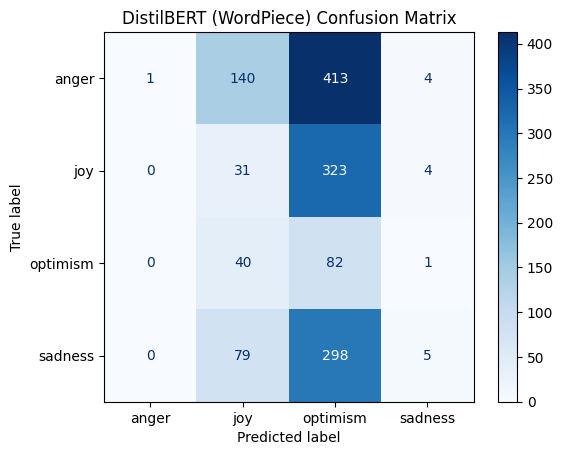

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_bert = test_df['distilbert_pred']
cm_bert = confusion_matrix(y_true, y_pred_bert, labels=candidate_labels)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=candidate_labels)
disp_bert.plot(cmap=plt.cm.Blues)
plt.title("DistilBERT (WordPiece) Confusion Matrix")
plt.show()

In [19]:
import pandas as pd
report_df = pd.DataFrame(results["DistilRoBERTa (BPE)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,0.343915,0.116487,0.174029,558.000000
joy,0.071429,0.030726,0.042969,358.000000
optimism,0.044693,0.065041,0.052980,123.000000
sadness,0.250278,0.589005,0.351288,382.000000
accuracy,0.217452,0.217452,0.217452,0.217452
macro avg,0.177579,0.200315,0.155317,1421.000000
weighted avg,0.224194,0.217452,0.178184,1421.000000


In [20]:
report_df.to_markdown()

'|              |   precision |    recall |   f1-score |     support |\n|:-------------|------------:|----------:|-----------:|------------:|\n| anger        |   0.343915  | 0.116487  |  0.174029  |  558        |\n| joy          |   0.0714286 | 0.0307263 |  0.0429688 |  358        |\n| optimism     |   0.0446927 | 0.0650407 |  0.0529801 |  123        |\n| sadness      |   0.250278  | 0.589005  |  0.351288  |  382        |\n| accuracy     |   0.217452  | 0.217452  |  0.217452  |    0.217452 |\n| macro avg    |   0.177579  | 0.200315  |  0.155317  | 1421        |\n| weighted avg |   0.224194  | 0.217452  |  0.178184  | 1421        |'

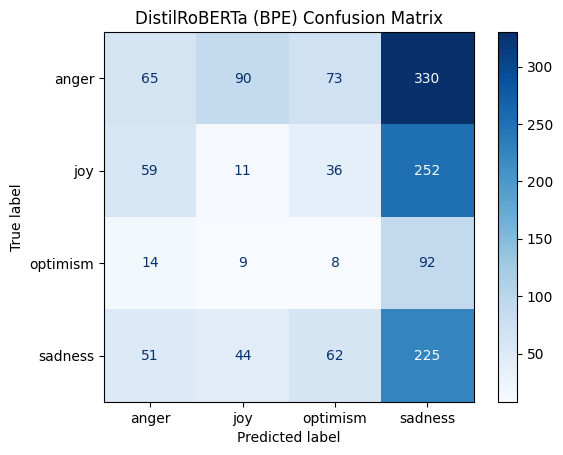

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_rob = test_df['distilroberta_pred']
cm_rob = confusion_matrix(y_true, y_pred_rob, labels=candidate_labels)
disp_rob = ConfusionMatrixDisplay(confusion_matrix=cm_rob, display_labels=candidate_labels)
disp_rob.plot(cmap=plt.cm.Blues)
plt.title("DistilRoBERTa (BPE) Confusion Matrix")
plt.show()

In [22]:
import pandas as pd
from analysis import show_tokenization

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot.")
print("Displaying 8 samples with tokenization splits:\n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 1003 samples misclassified by both models in zero-shot.
Displaying 8 samples with tokenization splits:

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: That morning when you get half-way to work and THEN realize the 4 year old is still in the back seat.  #backtrack
  WordPiece (DistilBERT): ['that', 'morning', 'when', 'you', 'get', 'half', '-', 'way', 'to', 'work', 'and', 'then', 'realize', 'the', '4', 'year', 'old', 'is', 'still', 'in', 'the', 'back', 'seat', '.', '#', 'back', '##tra', '##ck']
  BPE (DistilRoBERTa): ['That', 'Ġmorning', 'Ġwhen', 'Ġyou', 'Ġget', 'Ġhalf', '-', 'way', 'Ġto', 'Ġwork', 'Ġand', 'ĠTHEN', 'Ġrealize', 'Ġthe', 'Ġ4', 'Ġyear', 'Ġold', 'Ġis', 'Ġstill', 'Ġin', 'Ġthe', 'Ġback', 'Ġseat', '.', 'Ġ', 'Ġ#', 'back', 'track']

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: There is much in the world to make us #afraid. There is much more in our faith to make us #unafraid.
  WordPiece (DistilBERT): ['there', 'is

In [23]:
import pandas as pd
from analysis import show_tokenization

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot: \n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 1003 samples misclassified by both models in zero-shot: 

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: That morning when you get half-way to work and THEN realize the 4 year old is still in the back seat.  #backtrack
  WordPiece (DistilBERT): ['that', 'morning', 'when', 'you', 'get', 'half', '-', 'way', 'to', 'work', 'and', 'then', 'realize', 'the', '4', 'year', 'old', 'is', 'still', 'in', 'the', 'back', 'seat', '.', '#', 'back', '##tra', '##ck']
  BPE (DistilRoBERTa): ['That', 'Ġmorning', 'Ġwhen', 'Ġyou', 'Ġget', 'Ġhalf', '-', 'way', 'Ġto', 'Ġwork', 'Ġand', 'ĠTHEN', 'Ġrealize', 'Ġthe', 'Ġ4', 'Ġyear', 'Ġold', 'Ġis', 'Ġstill', 'Ġin', 'Ġthe', 'Ġback', 'Ġseat', '.', 'Ġ', 'Ġ#', 'back', 'track']

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: There is much in the world to make us #afraid. There is much more in our faith to make us #unafraid.
  WordPiece (DistilBERT): ['there', 'is', 'much', 'in', 'the', 'world', 'to', 'make',

In [24]:
import pandas as pd
test_df['label_str'] = test_df['label'].map(id_labels)

both_wrong = test_df[(test_df['distilbert_pred'] != test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

bert_right_rob_wrong = test_df[(test_df['distilbert_pred'] == test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

rob_right_bert_wrong = test_df[(test_df['distilroberta_pred'] == test_df['label_str']) & (test_df['distilbert_pred'] != test_df['label_str'])].head(8)

print(f"Both wrong: {len(both_wrong)}")
print(f"DistilBERT right, DistilRoBERTa wrong: {len(bert_right_rob_wrong)}")
print(f"DistilRoBERTa right, DistilBERT wrong: {len(rob_right_bert_wrong)}")

both_wrong_indices = both_wrong.index.tolist()
bert_right_rob_wrong_indices = bert_right_rob_wrong.index.tolist()
rob_right_bert_wrong_indices = rob_right_bert_wrong.index.tolist()


Both wrong: 8
DistilBERT right, DistilRoBERTa wrong: 8
DistilRoBERTa right, DistilBERT wrong: 8


In [25]:
from transformers import AutoTokenizer

tokenizer_bert = DistilBERT_zero_shot_pipeline.tokenizer
tokenizer_rob = DistilRoBERTa_zero_shot_pipeline.tokenizer

def analyze_tokenization(df, title):
    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['label_str']
        pred_bert = row['distilbert_pred']
        pred_rob = row['distilroberta_pred']

        tokens_bert = tokenizer_bert.tokenize(text)
        tokens_rob = tokenizer_rob.tokenize(text)

        print(f"Text: {text}")
        print(f"True: {true_label} | DistilBERT Pred: {pred_bert} | DistilRoBERTa Pred: {pred_rob}")
        print(f"WordPiece (DistilBERT): {tokens_bert}")
        print(f"BPE (DistilRoBERTa): {tokens_rob}")

analyze_tokenization(both_wrong, "Misclassified by BOTH")
analyze_tokenization(bert_right_rob_wrong, "DistilBERT Right, DistilRoBERTa Wrong")
analyze_tokenization(rob_right_bert_wrong, "DistilRoBERTa Right, DistilBERT Wrong")


Text: @user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an open door, but still...
True: anger | DistilBERT Pred: joy | DistilRoBERTa Pred: optimism
WordPiece (DistilBERT): ['@', 'user', 'interesting', 'choice', 'of', 'words', '.', '.', '.', 'are', 'you', 'confirming', 'that', 'governments', 'fund', '#', 'terrorism', '?', 'bit', 'of', 'an', 'open', 'door', ',', 'but', 'still', '.', '.', '.']
BPE (DistilRoBERTa): ['@', 'user', 'ĠInteresting', 'Ġchoice', 'Ġof', 'Ġwords', '...', 'ĠAre', 'Ġyou', 'Ġconfirming', 'Ġthat', 'Ġgovernments', 'Ġfund', 'Ġ#', 'terrorism', '?', 'ĠBit', 'Ġof', 'Ġan', 'Ġopen', 'Ġdoor', ',', 'Ġbut', 'Ġstill', '...']
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relationships
True: joy | DistilBERT Pred: optimism | DistilRoBERTa Pred: sadness
WordPiece (DistilBERT): ['@', 'user', 'welcome', 'to', '#', 'mps', '##v', '##t', '!', 'we', 'are', 'delighted', 'to', 'have', 'you', '!', '#', 'grateful

In [26]:
import json
with open("error_analysis_indices.json", "w") as f:
    json.dump({
        "both_wrong": both_wrong_indices,
        "bert_right_rob_wrong": bert_right_rob_wrong_indices,
        "rob_right_bert_wrong": rob_right_bert_wrong_indices
    }, f)
print("Saved indices to error_analysis_indices.json")


Saved indices to error_analysis_indices.json
